# Analysis of $\gamma$ Doradus stars

In [9]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import os
import sys
import glob
import scipy
import numpy as np
import pandas as pd
import scipy as sp
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.optimize import curve_fit
from matplotlib import patches
from matplotlib.ticker import FuncFormatter

# PlatoSim extra
import natsort
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot       as pt
import platosim.noise      as ns
import platosim.utilities  as ut
import platosim.statistics as st
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [11]:
# Define paths used throughout
star = 'GDOR'
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
path = f'/lhome/nicholas/software/workdir/mocka/analysis/{star}'
patha = f'{path}/affogato'
pathc = f'{path}/cortado'
pathd = f'{path}/doppio'
pathv = f'{path}/varsource'

---
## Plot final light curves
---

<IPython.core.display.Javascript object>


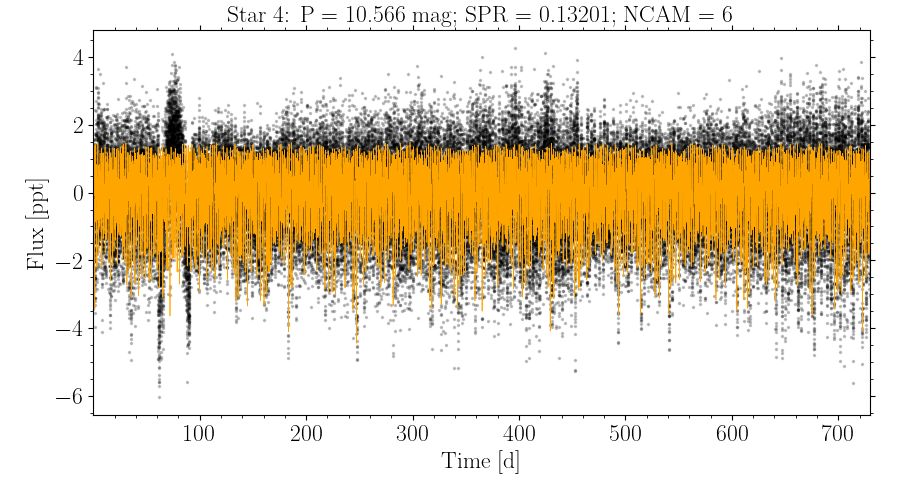

,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,4,5614219178756002304,115.536548,-25.213824,10.566355,1,1,2,2,2257.227668,316.783327,19.465001,-76.777900,-41.930098,5,0.132014
1,4,5614219178756002304,115.536548,-25.213824,10.566355,1,1,6,2,2257.103405,317.055312,19.463896,-76.773004,-41.927861,5,0.113298
2,4,5614219178756002304,115.536548,-25.213824,10.566355,1,2,2,2,2243.027104,330.520746,19.395116,-76.530627,-41.674488,5,0.115146
3,4,5614219178756002304,115.536548,-25.213824,10.566355,1,2,6,2,2242.903072,330.792328,19.394012,-76.525738,-41.672255,5,0.097184
4,4,5614219178756002304,115.536548,-25.213824,10.566355,1,3,2,2,2252.474246,317.537212,19.454116,-76.764330,-41.844536,5,0.106245


In [150]:
starID = f'{4}'.zfill(9)

# Fetch simulation table
dt = pd.read_feather(f'{patha}/table/table_{starID}.ftr')

# Fetch final ligth curve
lc = LightCurve(f'{patha}/final/lc_{starID}.ftr', mode="final")
df = lc.data()

# Load variable template
dv = pd.read_feather(f'{pathv}/templates/varsource_{starID}_001.ftr')
flux_var = (1 - 10**(0.4*dv.dmag)) * 1e3
dv.time /= 86400

# Plot final light curve
# dv.flux -= dv.flux.median()
# fig, ax = plt.subplots(1,1, figsize=(8,6))
fig, ax = lc.plot(flux_unit='ppt', median_filter=False, legend=False)
ax.plot(dv.time, flux_var, '-', c='orange', lw=0.5)

# plt.errorbar(df.time, df.flux, yerr=df.flux_err, fmt=".", color='k', alpha=0.1, ms=1)
ax.set_title(f'Star {int(starID)}: P = {dt.mag[0]:.3f} mag; SPR = {dt.SPR[0]:.5f}; NCAM = {int(dt.shape[0]/8)}')
dt.head()

---
## Test to compare input and output
---

In [154]:
# Load star results
starID = f'{4}'.zfill(9)
dm = pd.read_feather(f'{patha}/modes/modes_{starID}.ftr')
dp = pd.read_feather(f'{pathv}/parameters/{starID}_parameters.ftr')
df = pd.read_feather(f'{pathv}/pulsations/{starID}_pulsations.ftr')

# Correct for gamma factor
df.ampl /= 2.2

# Convert dmag to ppm
df.ampl = (1 - ut.fromMagToFlux(df.ampl)) * 1e6

# Fetch input frequencies in pettern
f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day for i in range(dp.N_modes[0])])

# Get pattern
dex_df = np.array([ut.findNearestIndex(df.freq, f_i[i]) for i in range(dp.N_modes[0])])
dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
df0 = df.loc[dex_df].reset_index(drop=True)
dm0 = dm.loc[dex_dm].reset_index(drop=True)

# O-C plot
f_oc = df0.freq.to_numpy() - dm0.freq.to_numpy()
A_oc = df0.ampl.to_numpy() - dm0.ampl.to_numpy()
dm1 = dm[dm.passed_snr]

# Remove matches above 0.01 c/d in the OC diagram
x = 0.0005
dex = np.where((np.abs(f_oc) > x))[0]
dm0 = dm0.drop(index=dex)
f0_oc = np.delete(f_oc, dex)
A0_oc = np.delete(A_oc, dex)

print(f'Stellar magnitude  : {dp.Pmag[0]:.4f} mag')
print(f'Limiting amplitude : {dm.ampl.min():.4f} ppm')
print(f'Number of modes    : {dm0.shape[0]}/{dp.N_modes[0]}')
print(f'RMS O-C amplitude  : {ut.rootMeanSquare(A0_oc):.4f} ppm')
print(f'RMS O-C frequency  : {ut.rootMeanSquare(f0_oc)*1e6:.4f} ppm/d')

Stellar magnitude  : 10.5664 mag
Limiting amplitude : 19.7985 ppm
Number of modes    : 14/15
RMS O-C amplitude  : 19.0451 ppm
RMS O-C frequency  : 55.6654 ppm/d


<IPython.core.display.Javascript object>


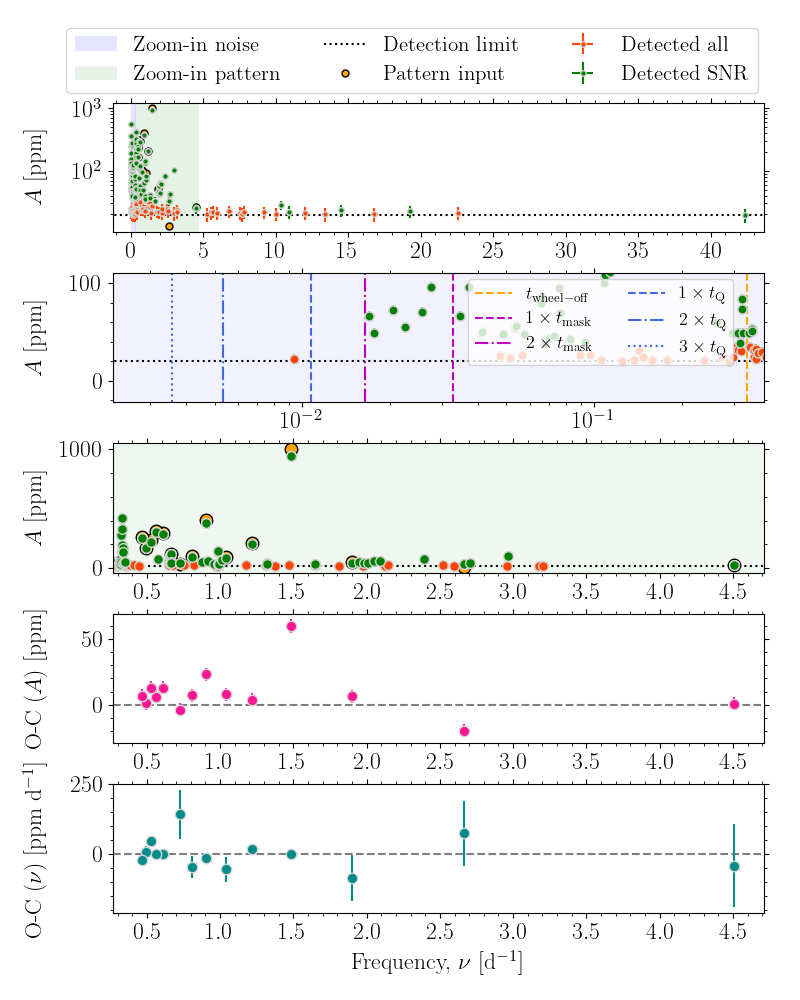

In [152]:
# EXAMPLE PLOT OF MODE EXTRACTION
fig, ax = plt.subplots(5, 1, figsize=(8,10))

# Full range
xmin = np.min([df0.freq.min(), dm.freq.min()])
xmax = np.max([df0.freq.max(), dm.freq.max()])
xlim0 = pt.getAxesMinMax(x=[xmin, xmax], percentage=3)

# Zoom-in one systematics
dm_sys = dm.loc[:2] #[~(dm.freq == dm0.freq)]
xlim1 = (0, 0.38) #pt.getAxesMinMax(x=dm_sys.freq.to_numpy(), percentage=10)
ylim1 = pt.getAxesMinMax(y=dm_sys.ampl.to_numpy(), percentage=100)

# Zoom-in on mode pattern
xlim2 = pt.getAxesMinMax(x=df.freq.to_numpy(), percentage=5)[::-1]
ylim2 = pt.getAxesMinMax(x=df.ampl.to_numpy(), percentage=5)

# Plot all modes detected
ax[0].axvspan(0,        xlim1[1], color='b', alpha=0.1, lw=0, label='Zoom-in noise')
ax[0].axvspan(xlim2[0], xlim2[1], color='g', alpha=0.1, lw=0, label='Zoom-in pattern')
ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit') 
ax[0].plot(df0.freq, df0.ampl, 'o', ms=5, c='orange', mec='k', label='Pattern input')
ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, 
               mec='lightgray', color="orangered",  label='Detected all')
ax[0].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=8, 
               mec='lightgray', color="green", label='Detected SNR')
handles, labels = ax[0].get_legend_handles_labels()
order = [0,1,2,3,4,5]
ax[0].legend([handles[i] for i in order], [labels[i] for i in order], 
             loc='upper center', ncol=3, bbox_to_anchor=(0.46, 1.66), fontsize=15.2)
ax[0].set_ylabel(r'$A$ [ppm]')
ax[0].set_yscale('log')
ax[0].set_xlim(xlim0)

# Zoom-in on noise
ax[1].axvspan(xlim1[0], xlim1[1], color='b', alpha=0.05, lw=0)
ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k')
ax[1].axvline(x=1/3,                    ls='--', c='orange',    label=r'$t_{\rm wheel-off}$')
ax[1].axvline(x=1/(ut.quarter()/3),     ls='--', c='m',     label=r'$1 \times t_{\rm mask}$')
ax[1].axvline(x=1/(ut.quarter()/3*2),   ls='-.', c='m',     label=r'$2 \times t_{\rm mask}$')
ax[1].axvline(x=1/(1*(ut.quarter()+2)), ls='--', c='royalblue', label=r'$1 \times t_{\rm Q}$')
ax[1].axvline(x=1/(2*(ut.quarter()+2)), ls='-.', c='royalblue', label=r'$2 \times t_{\rm Q}$')
ax[1].axvline(x=1/(3*(ut.quarter()+2)), ls=':',  c='royalblue', label=r'$3 \times t_{\rm Q}$')
ax[1].errorbar(dm.freq, dm.ampl, xerr=dm.freq_err, yerr=dm.ampl_err,  fmt=".", ms=13, 
               mec='lightgray', color="orangered",  label='Detected all')
ax[1].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=13, 
               mec='lightgray', color="green", label='Detected SNR')
handles, labels = ax[1].get_legend_handles_labels()
order = [0,1,2,3,4,5]
ax[1].legend([handles[i] for i in order], [labels[i] for i in order],
             loc='upper center', ncol=2, bbox_to_anchor=(0.75, 1.02), fontsize=13)
ax[1].set_ylabel(r'$A$ [ppm]')
ax[1].set_xscale('log')
ax[1].set_xlim(xlim1)
ax[1].set_ylim(ylim1)

# Zoom-in of pattern
ax[2].axvspan(xlim2[0], xlim2[1], color='g', alpha=0.06, lw=0)
ax[2].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
ax[2].plot(df0.freq, df0.ampl, 'o', ms=9, c='orange', mec='k')
ax[2].errorbar(dm.freq, dm.ampl, xerr=dm.freq_err, yerr=dm.ampl_err, fmt=".", ms=14, 
               mec='lightgray', color="orangered")
ax[2].errorbar(dm1.freq, dm1.ampl, xerr=dm1.freq_err, yerr=dm1.ampl_err, fmt=".", ms=14, 
               mec='lightgray', color="green")
ax[2].set_ylabel(r'$A$ [ppm]')
# ax[2].set_yscale('log')
ax[2].set_xlim(xlim2)

# OC diagram for amplitudes
ax[3].plot([xlim2[0], xlim2[1]], [0, 0], 'k--', alpha=0.5)
ax[3].errorbar(dm0.freq, A0_oc, xerr=None, yerr=dm0.ampl_err, fmt=".", ms=15, 
               mec='lightgray', color="deeppink")
ax[3].set_ylabel(r'O-C ($A$) [ppm]')
ax[3].set_xlim(xlim2)

# OC diagram for frequencies
ax[4].plot([xlim2[0], xlim2[1]], [0, 0], 'k--', alpha=0.5)
ax[4].errorbar(dm0.freq, f0_oc*1e6, xerr=None, yerr=dm0.freq_err*1e6, fmt=".", ms=15, 
               mec='lightgray', color="darkcyan")
ax[4].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[4].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
ax[4].set_xlim(xlim2)

# Settings
for i in range(5): ax[i].get_yaxis().set_label_coords(-0.10, 0.5)
plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison.png', bbox_inches='tight', dpi=200)

In [ ]:
# fig, ax = plt.subplots(3, 1, figsize=(8,8))

# xlim0 = pt.getAxesMinMax(x=dm.freq.to_numpy(),  percentage=1)
# xlim1 = pt.getAxesMinMax(x=dm0.freq.to_numpy(), percentage=1)

# ax[0].axvspan(df0.freq.min(), df0.freq.max(), color='green', alpha=0.3, lw=0, label='Zoom region')
# ax[0].axhline(y=dm.ampl.min(), xmin=xlim0[1], xmax=xlim0[0], ls=':', c='k', label='Detection limit')
# ax[0].plot(df.freq,  df.ampl,  'o', ms=5, c='orange', mec='k', label='Input all')
# ax[0].plot(df0.freq, df0.ampl, '+', ms=5, c='k', label='Input pattern')
# ax[0].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=8, mec='lightgray', color="b", label='Detected all')
# ax[0].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=8, mec='lightgray', color="deeppink", label='Detected pattern')
# ax[0].legend(loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.55), fontsize=15)
# ax[0].set_ylabel(r'$A$ [ppm]')
# ax[0].set_yscale('log')
# ax[0].set_xlim(xlim0)

# ax[1].axvspan(xlim1[0], xlim1[1], color='green', alpha=0.1, lw=0)
# ax[1].axhline(y=dm.ampl.min(), xmin=xlim0[0], xmax=xlim0[1], ls=':', c='k')
# ax[1].plot(df.freq,  df.ampl,  'o', ms=8, c='orange', mec='k')
# ax[1].plot(df0.freq, df0.ampl, '+', ms=8, c='k')
# ax[1].errorbar(dm.freq,  dm.ampl,  xerr=dm.freq_err,  yerr=dm.ampl_err,  fmt=".", ms=10, mec='lightgray', color="b")
# ax[1].errorbar(dm0.freq, dm0.ampl, xerr=dm0.freq_err, yerr=dm0.ampl_err, fmt=".", ms=10, mec='lightgray', color="deeppink")
# ax[1].set_ylabel(r'$A$ [ppm]')
# ax[1].set_yscale('log')
# ax[1].set_xlim(xlim1[1], xlim1[0])

# ax[2].plot([df0.freq.min(), df0.freq.max()], [0, 0], 'k--', alpha=0.5)
# ax[2].errorbar(dm0.freq, f0_oc*1e4, xerr=None, yerr=dm0.freq_err*1e4, fmt=".", ms=15, mec='lightgray', color="g")
# ax[2].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
# ax[2].set_ylabel(r'O-C ($\nu$) [ppm d$^{-1}$]')
# ax[2].set_xlim(xlim1[1], xlim1[0])

# plt.tight_layout(h_pad=0.1);
# fig.savefig(f'{fdir}/FrequencyModelComparison_test0.png', bbox_inches='tight', dpi=200)

---
## Distribution of input modes
---

In [12]:
folders_parameters = natsort.natsorted(glob.glob(f'{pathv}/parameters/*'))
folders_pulsations = natsort.natsorted(glob.glob(f'{pathv}/pulsations/*'))

# Load all pulsation modes
N = len(folders_parameters)
N_modes = np.zeros(N)
dm = pd.DataFrame()
for m,i,j in zip(range(N), folders_parameters, tqdm(folders_pulsations, bar_format=ut.tqdmBar())):    
    
    # Parameter file
    df_parameters = pd.read_feather(i)
    n = int(df_parameters.N_modes)
    N_modes[m] = n
    
    # Pulsation file
    df_pulsations = pd.read_feather(j)
    
    # Save only pulsation modes
    dm = pd.concat([dm, df_pulsations[:n]])

100%|█████████████████████████████████████████████████▉| 3999/4000 [00:18<00:00,


<IPython.core.display.Javascript object>


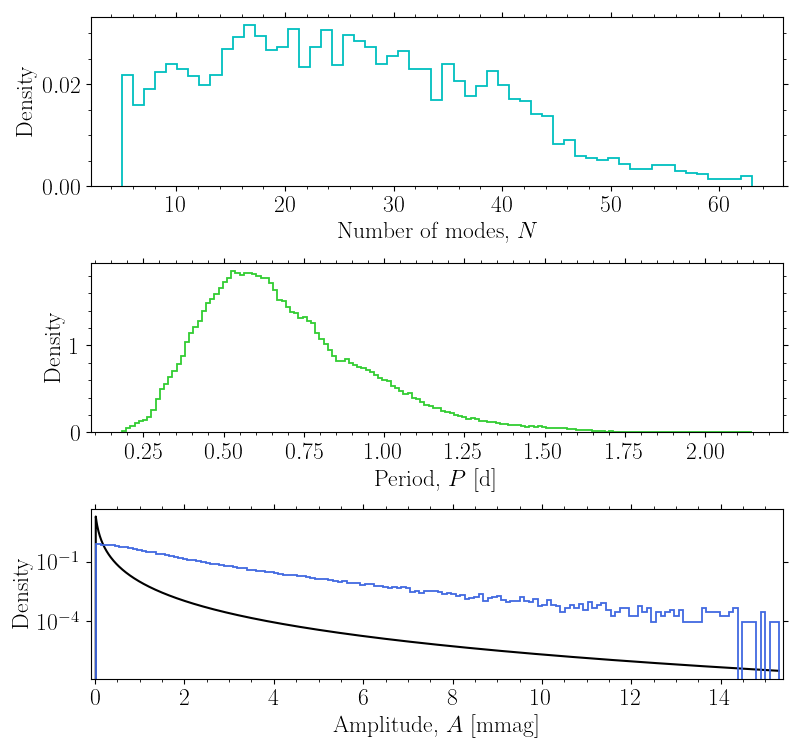

In [16]:
# Histograms
panels = 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(N_modes, bins=int(np.max(N_modes)-6), histtype='step', density=True, ec='c', lw=1.3)
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(1/dm.freq, bins=150, histtype='step', density=True, ec='limegreen', lw=1.3)
# ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_xlabel(r'Period, $P$ [d]')
ax[1].set_ylabel('Density')

A = dm.ampl * 1e3
param = [1.3177392518412796, 0.0021808623780934554, 0.03156072917069115] # GDOR
# param = 
A_range = np.linspace(0, A.max(), 1000)
A_lognorm = scipy.stats.lognorm.pdf(A_range, param[0], loc=param[1], scale=param[2])

ax[2].plot(A_range, A_lognorm, 'k-', label='Log-norm fit')
ax[2].hist(A, bins=150, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[2].set_yscale('log')
ax[2].set_xlim(-0.1, A.max()+0.1)

# Settings
# ax[0].set_title(r'Input model for $\gamma$ Dor', pad=15)
for i in range(panels): ax[i].set_ylabel('Density')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

---
## Detection rates
---

In [215]:
files_table = natsort.natsorted(glob.glob(f'{patha}/table/*'))
files_modes = natsort.natsorted(glob.glob(f'{patha}/final/*'))

dv = pd.read_feather(files_table[0])
dv

,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR
0,1,2927662090803150592,106.425338,-23.488456,15.531684,1,1,2,2,3488.947759,2167.384128,17.374881,-43.467086,-64.101060,4,0.029821
1,1,2927662090803150592,106.425338,-23.488456,15.531684,1,1,6,2,3488.810873,2167.635823,17.373914,-43.462555,-64.098596,4,0.017655
2,1,2927662090803150592,106.425338,-23.488456,15.531684,1,2,2,2,3474.186281,2179.736706,17.302177,-43.244739,-63.835353,4,0.025375
3,1,2927662090803150592,106.425338,-23.488456,15.531684,1,2,6,2,3474.049660,2179.988115,17.301212,-43.240214,-63.832894,4,0.028592
4,1,2927662090803150592,106.425338,-23.488456,15.531684,1,3,2,2,3483.921168,2168.072742,17.357626,-43.454691,-64.010581,4,0.028746
5,1,2927662090803150592,106.425338,-23.488456,15.531684,1,3,6,2,3483.784335,2168.324382,17.356660,-43.450161,-64.008118,4,0.028312
6,1,2927662090803150592,106.425338,-23.488456,15.531684,1,4,2,2,3480.130153,2170.479440,17.340588,-43.411370,-63.942343,4,0.027511
7,1,2927662090803150592,106.425338,-23.488456,15.531684,1,4,6,2,3479.993380,2170.731016,17.339622,-43.406842,-63.939881,4,0.019767
8,1,2927662090803150592,106.425338,-23.488456,15.531684,1,5,2,2,3480.484818,2172.600562,17.337180,-43.373190,-63.948727,4,0.034507
9,1,2927662090803150592,106.425338,-23.488456,15.531684,1,5,6,2,3480.348064,2172.852115,17.336214,-43.368662,-63.946265,4,0.038881


In [216]:
def match_modes(file_parameters, file_pulsations, file_modes, file_table):

    # Load files from for varsource
    dp = pd.read_feather(file_parameters)
    do = pd.read_feather(file_pulsations)
    
    # Load results from simulations
    dt = pd.read_feather(file_table)
    dm = pd.read_feather(file_modes)
    
    # Correct for gamma factor
    do.ampl /= 2.2

    # Convert amplitudes [dmag -> ppm]
    do.ampl = (1 - ut.fromMagToFlux(do.ampl)) * 1e6

    # Fetch input frequencies in pettern
    f_i = 1 / np.array([dp.DeltaP0_day * ((1 + dp.slope)**i - 1)/dp.slope + dp.P0_day 
                        for i in range(dp.N_modes[0])])

    # Find indices of matching frequencies
    dex_do = np.array([ut.findNearestIndex(do.freq, f_i[i]) for i in range(dp.N_modes[0])])
    dex_dm = np.array([ut.findNearestIndex(dm.freq, f_i[i]) for i in range(dp.N_modes[0])])
    
    # Get pattern passed BIC criterion
    do_bic = do.loc[dex_do].reset_index(drop=True)
    dm_bic = dm.loc[dex_dm].reset_index(drop=True)

    # Get pattern passed SNR criterion
    do_snr = do_bic[dm_bic.passed_snr].reset_index(drop=True)
    dm_snr = dm_bic[dm_bic.passed_snr].reset_index(drop=True)
    
    # Compute O-C values [ppm]
    f_oc_bic = (dm_bic.freq.to_numpy() - do_bic.freq.to_numpy())
    f_oc_snr = (dm_snr.freq.to_numpy() - do_snr.freq.to_numpy())
    A_oc_bic = (dm_bic.ampl.to_numpy() - do_bic.ampl.to_numpy())
    A_oc_snr = (dm_snr.ampl.to_numpy() - do_snr.ampl.to_numpy())

    # Remove matches above O-C threshold
    x = 0.0005
    dex_bic = np.where((np.abs(f_oc_bic) > x))[0]
    dex_snr = np.where((np.abs(f_oc_snr) > x))[0]
    dm_bic = dm_bic.drop(index=dex_bic)
    dm_snr = dm_snr.drop(index=dex_snr)
    f_oc_bic = np.delete(f_oc_bic, dex_bic) * 1e6
    f_oc_snr = np.delete(f_oc_snr, dex_snr) * 1e6
    A_oc_bic = np.delete(A_oc_bic, dex_bic)
    A_oc_snr = np.delete(A_oc_snr, dex_snr)

    # Store values into data frame
    df_oc_bic = pd.DataFrame({'freq':dm_bic.freq, 'ampl':dm_bic.ampl,
                              'freq_oc':f_oc_bic, 'ampl_oc':A_oc_bic})
    df_oc_snr = pd.DataFrame({'freq':dm_snr.freq, 'ampl':dm_snr.ampl,
                              'freq_oc':f_oc_snr, 'ampl_oc':A_oc_snr})
    
    # Store in data frame
    dx = pd.DataFrame({'Pmag': dp.Pmag,
                       'ncam': dt.shape[0],
                       'rOA': dt.rOA.mean(),
                       'SPR': dt.SPR.mean(),
                       'A_max': dm.ampl.max(),
                       'A_limit': dm_bic.ampl.min(),
                       'N_input': dp.N_modes[0],
                       'N_bic': dm_bic.shape[0],
                       'N_snr': dm_snr.shape[0],
                       'f_rms_bic': ut.rootMeanSquare(f_oc_bic),
                       'f_rms_snr': ut.rootMeanSquare(f_oc_snr),
                       'A_rms_bic': ut.rootMeanSquare(A_oc_bic),
                       'A_rms_snr': ut.rootMeanSquare(A_oc_snr),
                      })
    
    return dx, df_oc_bic, df_oc_snr 

In [217]:
def fetch_all_modes(batch='affogato'):
    
    files_parameters = natsort.natsorted(glob.glob(f'{pathv}/parameters/*'))
    files_pulsations = natsort.natsorted(glob.glob(f'{pathv}/pulsations/*'))
    files_modes = natsort.natsorted(glob.glob(f'{path}/{batch}/modes/*'))
    files_table = natsort.natsorted(glob.glob(f'{path}/{batch}/table/*'))
    
    dx = pd.DataFrame()
    df_bic = pd.DataFrame()
    df_snr = pd.DataFrame()
    for i in tqdm(range(len(files_modes)), bar_format=ut.tqdmBar()):    

        dx0, df0_bic, df0_snr = match_modes(files_parameters[i], 
                                             files_pulsations[i], 
                                             files_modes[i], 
                                             files_table[i])
        dx = pd.concat([dx, dx0])
        df_bic = pd.concat([df_bic, df0_bic])
        df_snr = pd.concat([df_snr, df0_snr])
    
    return dx, df_bic, df_snr

In [218]:
dx, df_bic, df_snr = fetch_all_modes(batch='affogato')

100%|██████████████████████████████████████████████████| 4000/4000 [01:16<00:00,


In [163]:
dx

,Pmag,ncam,SPR,A_max,A_limit,N_input,N_bic,N_snr,f_rms_bic,f_rms_snr,A_rms_bic,A_rms_snr
0,15.531684,48,0.024932,928.450105,238.970697,12,7,6,92.913160,100.145751,37.030089,39.478786
0,11.503879,48,0.071460,1252.092025,35.932081,12,12,12,8.989267,8.989267,2.093017,2.093017
0,10.384502,48,0.005247,2291.719970,21.773468,26,26,26,19.967114,19.967114,122.873655,122.873655
0,10.566355,48,0.106967,938.798556,25.208593,15,14,14,55.665446,55.665446,19.045143,19.045143
0,13.212634,48,0.125337,960.170357,60.746125,13,12,12,31.591551,31.591551,59.493098,59.493098
...,...,...,...,...,...,...,...,...,...,...,...,...
0,11.500286,192,0.000195,824.789445,12.967011,34,34,34,71.203911,71.203911,30.641174,30.641174
0,13.450818,192,0.000000,741.510356,36.248931,10,9,9,25.440086,25.440086,33.347894,33.347894
0,14.548789,192,0.032423,1578.407196,104.381997,15,14,14,28.126650,28.126650,58.226091,58.226091
0,12.753219,184,0.114394,2804.718521,25.623011,18,17,16,88.030981,90.237933,55.523461,57.232081


### Recovery of mode counts

In [219]:
N = np.max([dx.N_input.max(), dx.N_bic.max(), dx.N_snr.max()])

count_input, bin_input = np.histogram(dx.N_input, bins=N, range=(0, N))
count_bic, bin_bic     = np.histogram(dx.N_bic,   bins=N, range=(0, N))
count_snr, bin_snr     = np.histogram(dx.N_snr,   bins=N, range=(0, N))

N_oc_bic = count_bic - count_input
N_oc_snr = count_snr - count_input

<IPython.core.display.Javascript object>


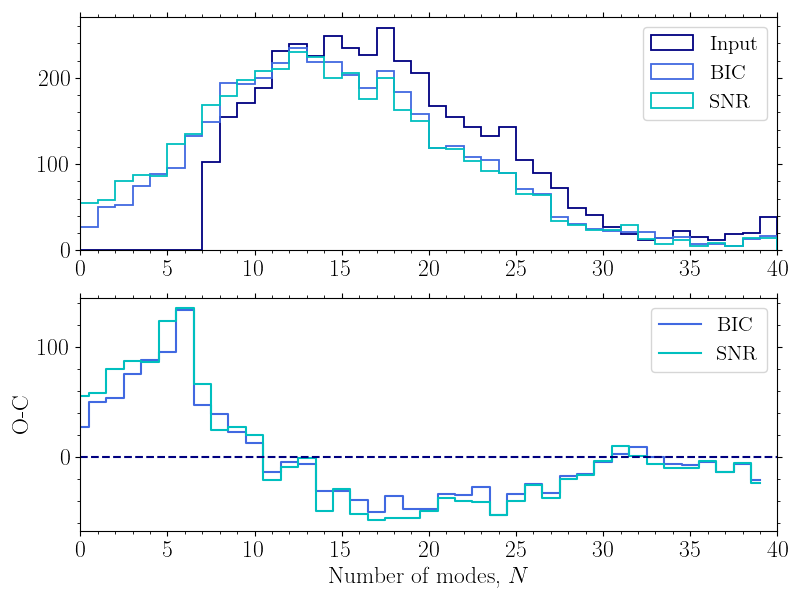

In [220]:
# Histograms
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(dx.N_input, bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='navy', label='Input')
ax[0].hist(dx.N_bic,   bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='royalblue', label='BIC')
ax[0].hist(dx.N_snr,   bins=N, range=(0, N), histtype='step', density=False, lw=1.3, ec='c', label='SNR')

ax[1].plot(range(0, N), N_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
ax[1].plot(range(0, N), N_oc_snr, '-', drawstyle='steps-mid', c='c', label='SNR')
ax[1].plot([0, N], [0, 0], '--', c='navy')
ax[1].set_ylabel('O-C')
ax[1].set_xlabel(r'Number of modes, $N$')

# ax[0].set_title(r'$\gamma$ Dor', pad=15)
for i in range(panels): 
    ax[i].set_xlim(0, N)
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

### Recovery of mode frequencies

In [221]:
N = 150
f_max = np.max(df_bic.freq)

count_input, bin_input = np.histogram(dm.freq,     bins=N, range=(0, f_max))
count_bic, bin_bic     = np.histogram(df_bic.freq, bins=N, range=(0, f_max))
count_snr, bin_snr     = np.histogram(df_snr.freq, bins=N, range=(0, f_max))

f_oc_bic = count_bic / count_input * 100
f_oc_snr = count_snr / count_input * 100

<IPython.core.display.Javascript object>


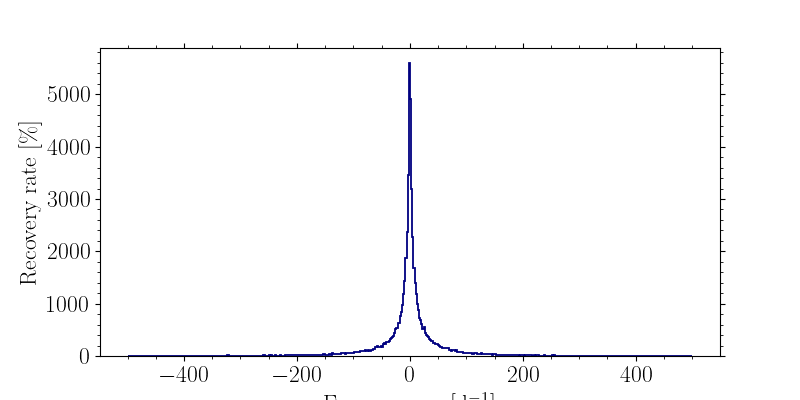

Text(0.5, 0, 'Frequency, $\\nu$ [d$^{-1}$]')

In [239]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.hist(df_bic.freq_oc, bins=500, histtype='step', density=False, lw=1.3, ec='navy', label='Input')

# ax.plot(np.linspace(0, f_max, N), f_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
# ax.plot(np.linspace(0, f_max, N), f_oc_snr, '-', drawstyle='steps-mid', c='c', label='SNR')
# ax.plot([0, N], [100, 100], '--', c='navy')
ax.set_ylabel('Recovery rate [\%]')
ax.set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')


<IPython.core.display.Javascript object>


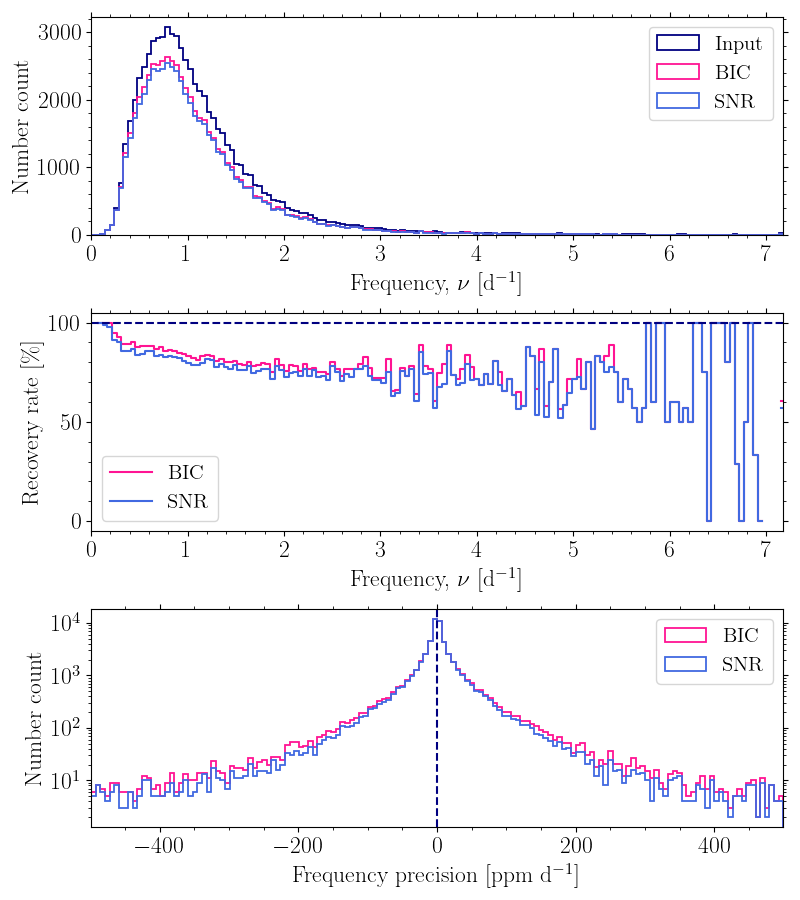

In [260]:
# FREQUENCY RECOVERY HISTOGRAMS
panels = 3
c = ['navy', 'deeppink', 'royalblue']

fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(dm.freq,     bins=N, range=(0, f_max), histtype='step', density=False, lw=1.3, ec=c[0], label='Input')
ax[0].hist(df_bic.freq, bins=N, range=(0, f_max), histtype='step', density=False, lw=1.3, ec=c[1], label='BIC')
ax[0].hist(df_snr.freq, bins=N, range=(0, f_max), histtype='step', density=False, lw=1.3, ec=c[2], label='SNR')
ax[0].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[0].set_ylabel('Number count')
ax[0].set_xlim(0, f_max)
# ax[0].set_yscale('log')

ax[1].plot(np.linspace(0, f_max, N), f_oc_bic, '-', drawstyle='steps-mid', c=c[1], label='BIC')
ax[1].plot(np.linspace(0, f_max, N), f_oc_snr, '-', drawstyle='steps-mid', c=c[2], label='SNR')
ax[1].axhline(y=100, color=c[0], linestyle='--')
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Recovery rate [\%]')
ax[1].set_xlim(0, f_max)

ax[2].hist(df_bic.freq_oc, bins=N, histtype='step', density=False, lw=1.3, ec=c[1], label='BIC')
ax[2].hist(df_snr.freq_oc, bins=N, histtype='step', density=False, lw=1.3, ec=c[2], label='SNR')
ax[2].axvline(x=0, color=c[0], linestyle='--')
ax[2].set_xlabel(r'Frequency precision [ppm d$^{-1}$]')
ax[2].set_ylabel('Number count')
ax[2].set_xlim(df_bic.freq_oc.min(), df_bic.freq_oc.max())
ax[2].set_yscale('log')

for i in range(panels): ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

### Recovery of modes amplitudes

In [223]:
N = 150
A = dm.ampl / 2.2
A_bic = 2.5*np.log10(df_bic.ampl / 1e6  + 1)
A_max = np.max(A_bic)

count_input, bin_input = np.histogram(A,     bins=N, range=(0, A_max))
count_bic, bin_bic     = np.histogram(A_bic, bins=N, range=(0, A_max))

A_oc_bic = count_bic / count_input * 100

<IPython.core.display.Javascript object>


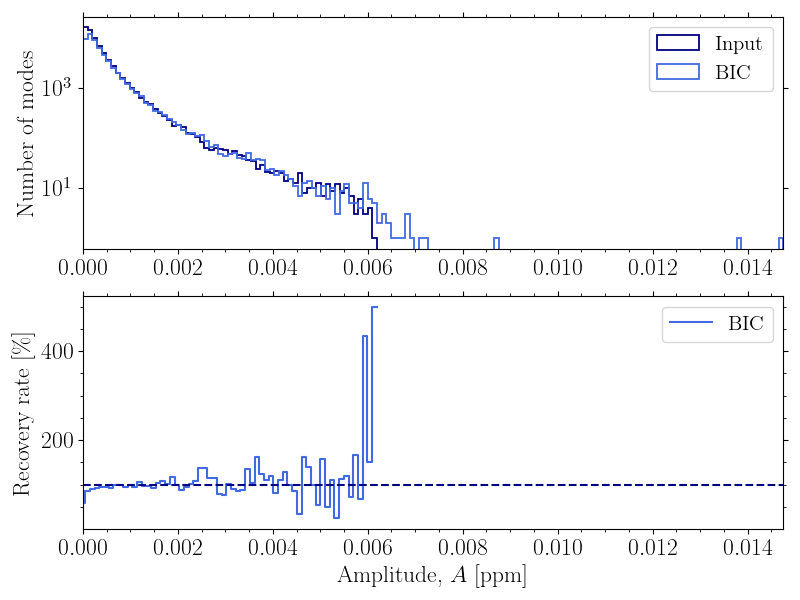

In [224]:
# AMPLITUDE RECOVERY HISTOGRAM
panels = 2
fig, ax = plt.subplots(panels, 1, figsize=(8, 3*panels))

ax[0].hist(A,     bins=N, range=(0, np.max(A_max)), histtype='step', density=False, lw=1.3, ec='navy',      label='Input')
ax[0].hist(A_bic, bins=N, range=(0, A_max),         histtype='step', density=False, lw=1.3, ec='royalblue', label='BIC')
# ax[0].plot(A_range, A_lognorm, 'k-', label='Log-norm fit')
ax[0].set_ylabel('Number of modes')
ax[0].set_yscale('log')

ax[1].plot(np.linspace(0, A_max, N), A_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
ax[1].plot([0, A_max], [100, 100], '--', c='navy')
ax[1].set_ylabel('Recovery rate [\%]')
ax[1].set_xlabel(r'Amplitude, $A$ [ppm]')

# ax[0].set_title(r'$\gamma$ Dor: Amplitde histogram', pad=15)
for i in range(panels): 
    ax[i].set_xlim(0, A_max)
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{fdir}/hist_parameters_dsct.png', bbox_inches='tight', dpi=200)

In [196]:
dx

,Pmag,ncam,SPR,A_max,A_limit,N_input,N_bic,N_snr,f_rms_bic,f_rms_snr,A_rms_bic,A_rms_snr
0,7.528481,48,0.000096,1092.277826,17.524173,14,14,14,8.126345,8.126345,55.905516,55.905516
0,7.529037,96,0.000000,2235.935339,13.992091,30,30,30,6.285672,6.285672,45.365622,45.365622
0,7.530000,192,0.004055,676.553642,18.781933,12,12,12,5.958782,5.958782,25.417839,25.417839
0,7.533352,96,0.000000,3075.890417,31.616388,10,10,10,17.242465,17.242465,69.524611,69.524611
0,7.536273,192,0.000000,1355.194113,12.459259,20,20,20,24.989318,24.989318,43.131692,43.131692
...,...,...,...,...,...,...,...,...,...,...,...,...
0,16.931847,96,0.003541,5773.765865,771.981922,19,4,3,131.623089,86.321981,311.426220,333.013059
0,16.952751,144,0.694103,426.804435,39.760931,19,5,3,194.006123,244.946948,759.011069,797.911563
0,16.995443,192,0.008083,2563.009686,686.964489,13,4,4,36.119197,36.119197,187.255450,187.255450
0,17.005024,48,0.141084,1086.220985,322.662589,8,1,1,75.686687,75.686687,814.661949,814.661949


In [225]:
from scipy.ndimage import median_filter

dx = dx.sort_values(by=['Pmag', 'ncam']).dropna()
m = 100

A_limit_med = median_filter(dx.A_limit, m)
A_rms_med   = median_filter(dx.A_rms_snr, m)
f_rms_med   = median_filter(dx.f_rms_snr, m)

dx06 = dx[dx.ncam == 48]
dx12 = dx[dx.ncam == 96]
dx18 = dx[dx.ncam == 144]
dx24 = dx[dx.ncam == 192]

A_limit_med06 = median_filter(dx06.A_limit, m)
A_limit_med12 = median_filter(dx12.A_limit, m)
A_limit_med18 = median_filter(dx18.A_limit, m)
A_limit_med24 = median_filter(dx24.A_limit, m)

A_rms_med06 = median_filter(dx06.A_rms_snr, m)
A_rms_med12 = median_filter(dx12.A_rms_snr, m)
A_rms_med18 = median_filter(dx18.A_rms_snr, m)
A_rms_med24 = median_filter(dx24.A_rms_snr, m)

<IPython.core.display.Javascript object>


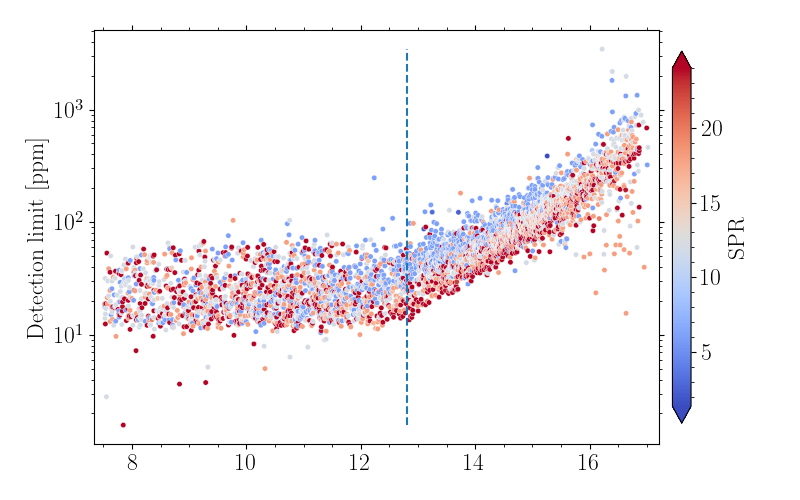

In [230]:
# Histograms
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
scat = ax.scatter(dx.Pmag, dx.A_limit, c=dx.ncam/8, marker='o', s=15, linewidth=0.3, edgecolor='w', cmap="coolwarm")
cbar = plt.colorbar(scat, extend='both', pad=0.02, shrink=0.9)

# ax.plot(dx06.Pmag, A_limit_med06, '-', lw=1.5, c='r')
# ax.plot(dx12.Pmag, A_limit_med12, '-', lw=1.5, c='tomato')
# ax.plot(dx18.Pmag, A_limit_med18, '-', lw=1.5, c='orange')
# ax.plot(dx24.Pmag, A_limit_med24, '-', lw=1.5, c='gold')
# ax.axvline(x=13, ymin=dx.A_limit.min(), ymax=dx.A_limit.max(), color='r')
ax.plot([12.8, 12.8], [dx.A_limit.min(), dx.A_limit.max()], '--')
# Colorbar
cbar.set_label('SPR')
# Settings
ax.set_ylabel('Detection limit [ppm]')
xlim = pt.getAxesMinMax(x=dx.Pmag.to_numpy(), percentage=2)
ax.set_xlim(xlim)
ax.set_yscale('log')
plt.tight_layout();

<IPython.core.display.Javascript object>


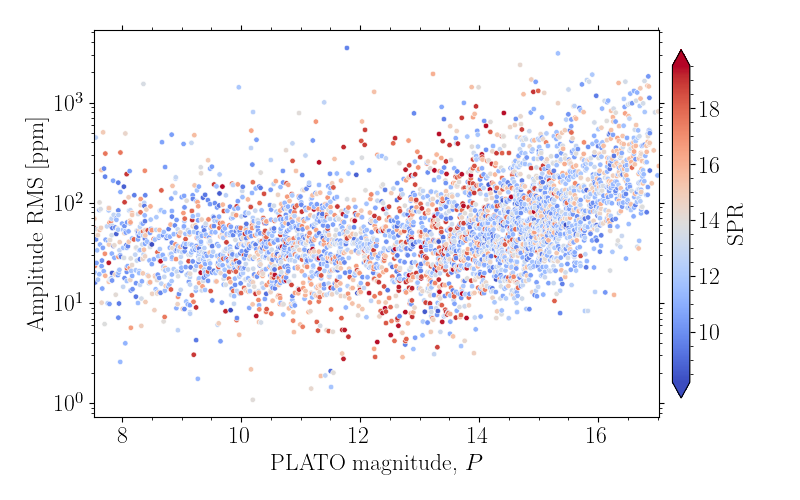

In [232]:
# Histograms
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
scat = ax.scatter(dx.Pmag, dx.A_rms_snr, c=dx.rOA, marker='o', s=15, linewidth=0.4, edgecolor='w', cmap="coolwarm")
cbar = plt.colorbar(scat, extend='both', pad=0.02, shrink=0.9)
# ax.plot(dx06.Pmag, A_rms_med06, '-', lw=1.5, c='r')
# ax.plot(dx12.Pmag, A_rms_med12, '-', lw=1.5, c='tomato')
# ax.plot(dx18.Pmag, A_rms_med18, '-', lw=1.5, c='orange')
# ax.plot(dx24.Pmag, A_rms_med24, '-', lw=1.5, c='gold')
# Labels
cbar.set_label('SPR')
ax.set_ylabel('Amplitude RMS [ppm]')
ax.set_xlabel(r'PLATO magnitude, $P$')
# Settings
ax.set_xlim(dx.Pmag.min(), dx.Pmag.max())
ax.set_yscale('log')
plt.tight_layout();

<IPython.core.display.Javascript object>


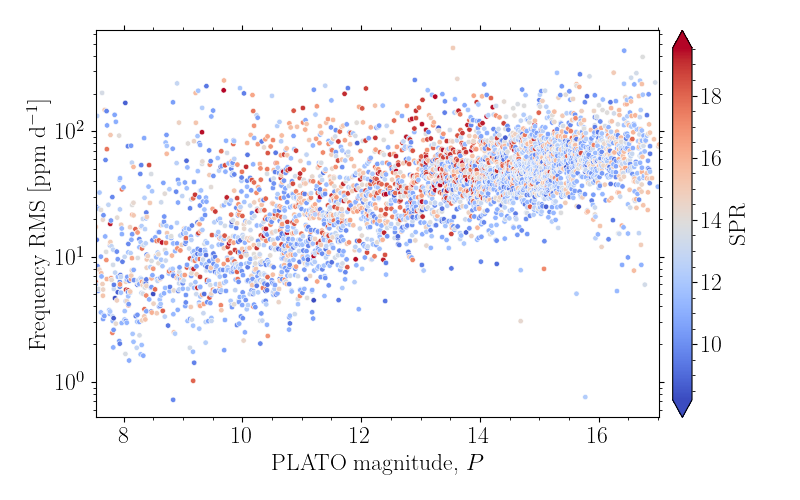

In [233]:
# Histograms
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
scat = ax.scatter(dx.Pmag, dx.f_rms_snr, c=dx.rOA, marker='o', s=15, linewidth=0.4, edgecolor='w', cmap="coolwarm")
cbar = plt.colorbar(scat, extend='both', pad=0.02, shrink=1)
# ax.plot(dx06.Pmag, A_rms_med06, '-', lw=1.5, c='r')
# ax.plot(dx12.Pmag, A_rms_med12, '-', lw=1.5, c='tomato')
# ax.plot(dx18.Pmag, A_rms_med18, '-', lw=1.5, c='orange')
# ax.plot(dx24.Pmag, A_rms_med24, '-', lw=1.5, c='gold')
# Labels
cbar.set_label('SPR')
ax.set_ylabel(r'Frequency RMS [ppm d$^{-1}$]')
ax.set_xlabel(r'PLATO magnitude, $P$')
# Settings
ax.set_xlim(dx.Pmag.min(), dx.Pmag.max())
ax.set_yscale('log')
plt.tight_layout();

<IPython.core.display.Javascript object>


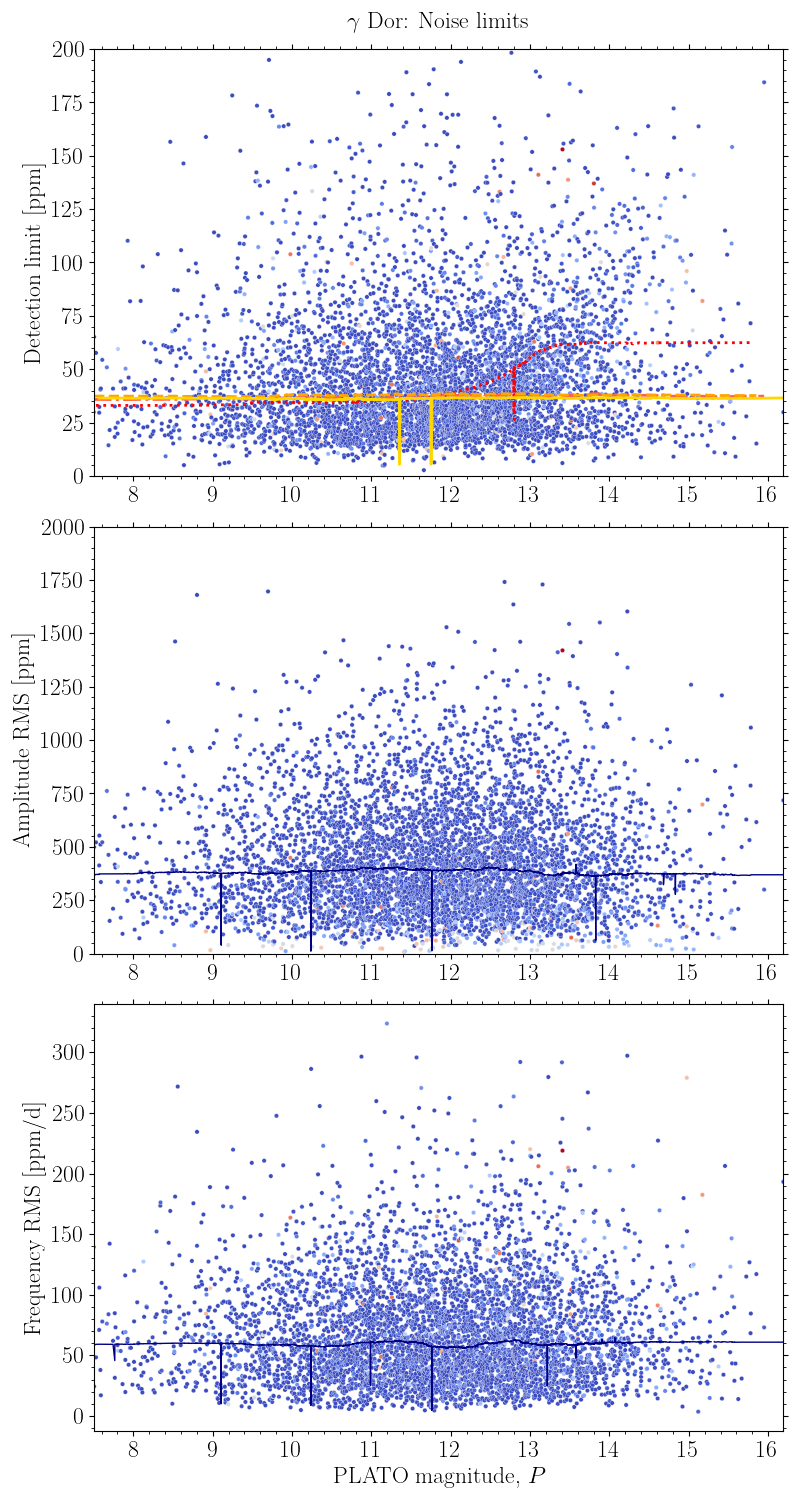

In [362]:

# Histograms
panels = 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 5*panels))

ax[0].scatter(dx.Pmag, dx.A_limit, c=dx.SPR, marker='o', s=10, linewidth=0.2, edgecolor='w', cmap="coolwarm")
# ax[0].plot(dx.Pmag, A_limit_med, '-', c='navy',   lw=1.0)
ax[0].plot(dx06.Pmag, A_limit_med06, ':',  lw=2.0, c='r')
ax[0].plot(dx12.Pmag, A_limit_med12, '-.', lw=2.0, c='tomato')
ax[0].plot(dx18.Pmag, A_limit_med18, '--', lw=2.0, c='orange')
ax[0].plot(dx24.Pmag, A_limit_med24, '-',  lw=2.0, c='gold')
ax[0].set_ylabel('Detection limit [ppm]')
ax[0].set_ylim(0, 200)
# cmap="viridis"

ax[1].scatter(dx.Pmag, dx.A_rms_snr, c=dx.SPR, marker='o', s=10, linewidth=0.2, edgecolor='w', cmap="coolwarm")
# ax[1].plot(dx.Pmag, dx.A_rms_snr, '.', c='orange', ms=2, mec='gray', lw=1)
ax[1].plot(dx.Pmag, A_rms_med, '-', c='navy',   lw=1.0)
ax[1].set_ylabel('Amplitude RMS [ppm]')
ax[1].set_ylim(0, 2000)

ax[2].scatter(dx.Pmag, dx.f_rms_snr, c=dx.SPR, marker='o', s=10, linewidth=0.2, edgecolor='w', cmap="coolwarm")
ax[2].plot(dx.Pmag, f_rms_med, '-', c='navy', lw=1.0)
ax[2].set_ylabel('Frequency RMS [ppm/d]')
ax[2].set_xlabel(r'PLATO magnitude, $P$')

# ax[0].set_yscale('log')

# ax[1].plot(np.linspace(0, A_max, N), A_oc_bic, '-', drawstyle='steps-mid', c='royalblue', label='BIC')
# ax[1].plot([0, A_max], [100, 100], '--', c='navy')
# ax[1].set_ylabel('Recovery rate [\%]')
# ax[1].set_xlabel(r'Amplitude, $A$ [ppm]')

ax[0].set_title(r'$\gamma$ Dor: Noise limits', pad=15)
for i in range(panels): 
    ax[i].set_xlim(dx.Pmag.min(), dx.Pmag.max())
#     ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);